# Carga de Datos

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="darkgrid")
df = pd.read_csv('BaseDatos/train.csv')
    
df.head()


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


# Limpieza de datos

## Eliminacion de datos duplicados

In [20]:
# ELIMINAR DUPLICADOS:
df.drop_duplicates(inplace=True)

# VALORES FALTANTES:
df.fillna(df.median(numeric_only=True), inplace=True)

# LIMPIAR DATOS:
if 'host_response_rate' in df.columns:
    df['host_response_rate'] = (
        df['host_response_rate']
        .astype(str)
        .str.replace('%', '', regex=False)
    )

    df['host_response_rate'] = pd.to_numeric(
        df['host_response_rate'],
        errors='coerce'
    )

print("Datos limpiados correctamente.")
print(df.info())


Datos limpiados correctamente.
<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               74111 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_veri

## Variable dependiente:

Precio:  depende en donde y qué contiene el airbnb

## Variable indpendiente:

Las variables independientes son aquellas utilizadas para explicar o predecir el precio del alojamiento, entre ellas:

bathrooms, bedrooms, beds, property_type, room_type, etc, etc, etc


## Selección de características

Para la selección de características se eligieron las variables con mayor relación con el precio del Airbnb y que aportan información importante al modelo

Las variables seleccionadas fueron:

- accommodates
- bathrooms
- bedrooms
- latitude
- longitude
- number_of_reviews
- cleaning_fee

Las cuáles, ayudan a explicar el comportamiento del precio debido a factores como:
- Capacidad del alojamiento
- Cantidad de habitaciones y baños
- Ubicación geográfica
- Popularidad del alojamiento
- Costos adicionales de limpieza

## Análisis de correlación

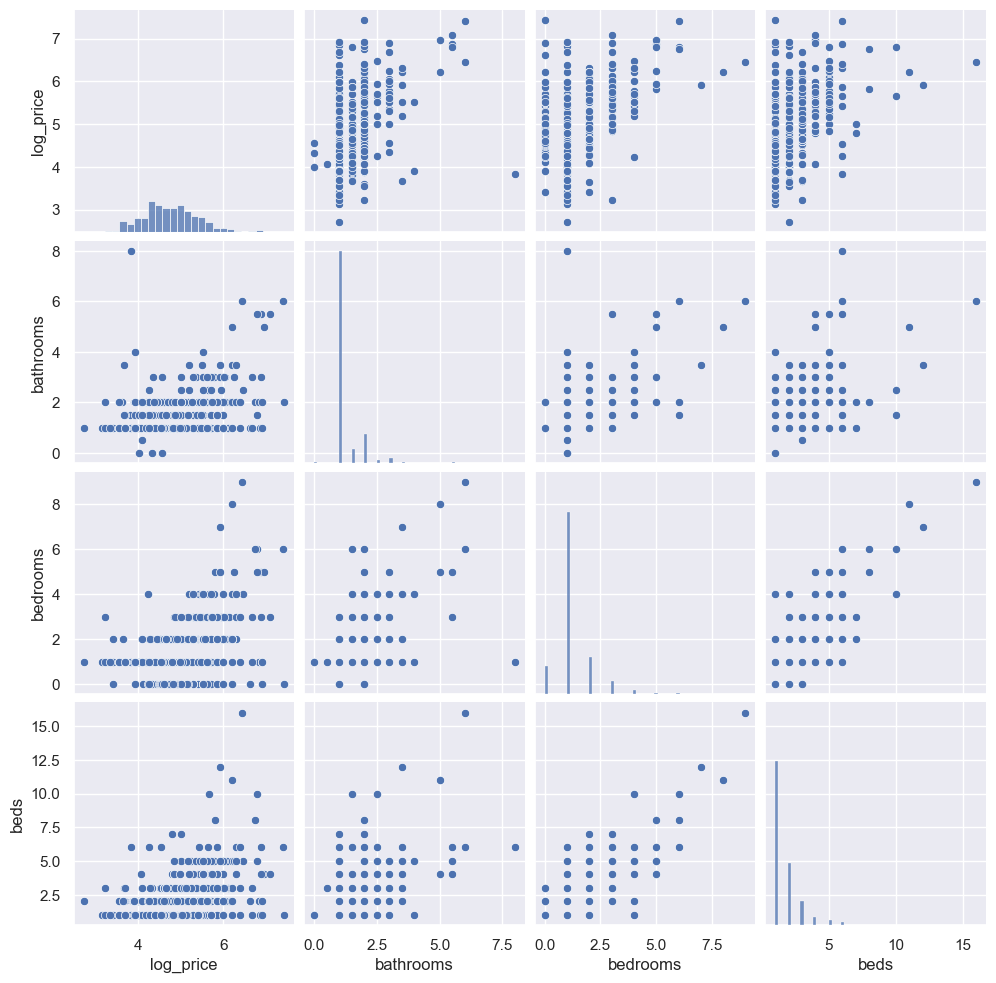

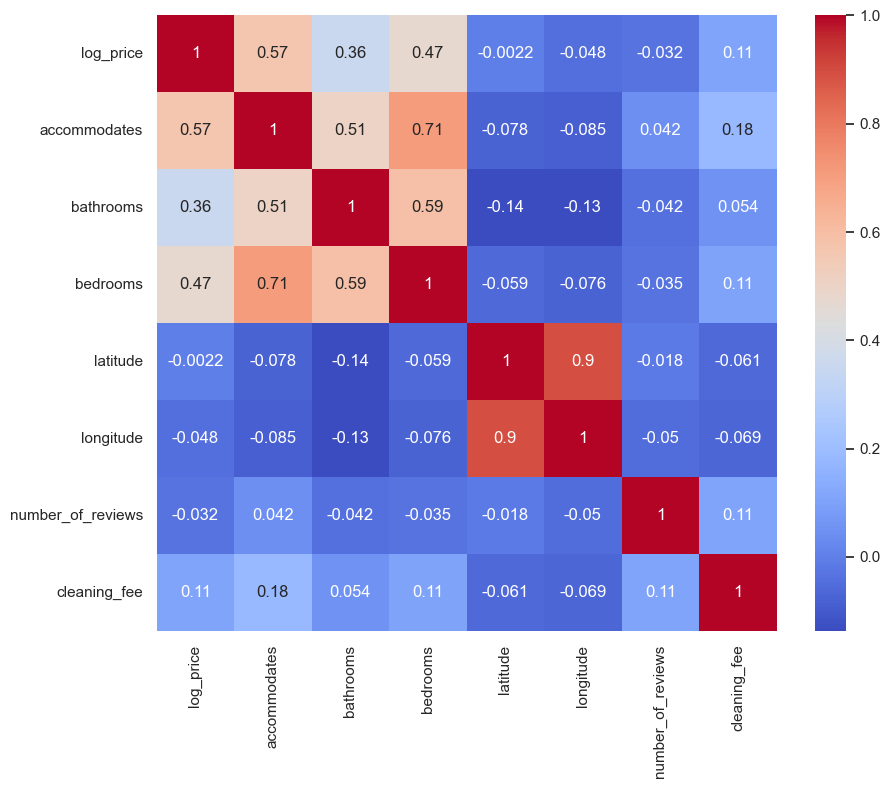

In [21]:
variables_pairplot = [
    'log_price',
    'bathrooms',
    'bedrooms',
    'beds',
]

sample_size = min(1000, len(df))

data = (
    df[variables_pairplot]
    .dropna()
    .sample(sample_size, random_state=42)
)

sns.pairplot(
    data,
    diag_kind='hist'
)

plt.show()

var_calor = df[[
    'log_price',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'latitude',
    'longitude',
    'number_of_reviews',
    'cleaning_fee'
]]

plt.figure(figsize=(10,8))
sns.heatmap(var_calor.corr(), annot=True, cmap='coolwarm')
plt.show()

# Division de datos

In [22]:
X = df[[
    'accommodates',
    'bathrooms',
    'bedrooms',
    'latitude',
    'longitude',
    'number_of_reviews',
    'cleaning_fee'
]]

y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Construcción y entrenamiento del modelo

In [23]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    'Valor Real': y_test,
    'Predicción': y_pred
})

print(comparacion.head(10))

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

       Valor Real  Predicción
4079     3.806662    4.754561
33735    4.941642    4.595851
69475    4.941642    5.120254
454      4.867534    5.199917
25153    3.663562    4.520139
42304    4.836282    5.229735
22686    5.220356    5.282108
20776    5.686975    4.485298
14934    3.555348    4.551628
39634    4.234107    4.927845
MSE: 0.34017434065180846
R²: 0.3378290998784734


# Evaluación del modelo

Se evalúa el modelo utilizando métricas tales como:
- Error Cuadrático Medio (MSE)
- Coeficiente de determinación (R²)

Además, se comparan las predicciones contra los valores reales mediante gráficas


Error Cuadrático Medio (MSE): 0.34017434065180846
Coeficiente R²: 0.3378290998784734


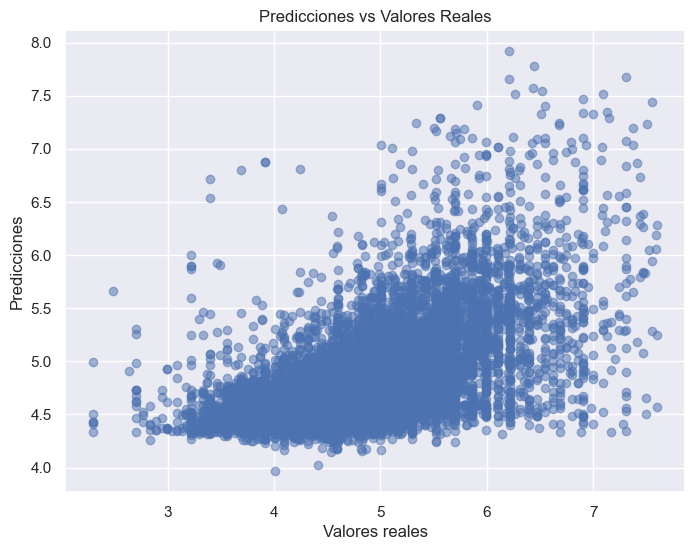

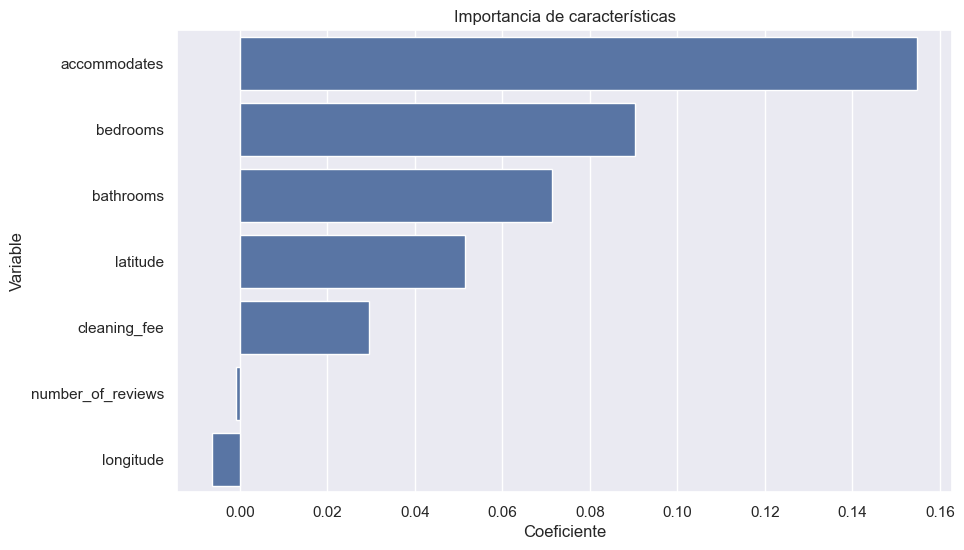

            Variable  Coeficiente
0       accommodates     0.154729
2           bedrooms     0.090254
1          bathrooms     0.071361
3           latitude     0.051475
6       cleaning_fee     0.029591
5  number_of_reviews    -0.000971
4          longitude    -0.006267


In [24]:
# MÉTRICAS:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse}")
print(f"Coeficiente R²: {r2}")

# GRÁFICA:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Valores Reales")
plt.show()

# VARIABLES:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coeficientes, x='Coeficiente', y='Variable')
plt.title("Importancia de características")
plt.show()

print(coeficientes)


# Interpretación de resultados

Los resultados muestran que variables como
- la cantidad de personas que puede alojar
- el número de habitaciones
- la ubicación
- la tarifa de limpieza
tienen una influencia importante en el precio final

El valor de R² indica qué tan bien el modelo logra explicar la variación de los precios, mientras que el MSE muestra el nivel de error promedio en las predicciones

La gráfica de predicciones vs valores reales permite observar qué tan cercanas son las predicciones del modelo respecto a los datos originales
